# Project 2: Student Exam Performance

## Scenario

This dataset has student academic, lifestyle, and socio-economic factors that affect exam performance. Things like study hours, attendance, sleep, motivation, parental involvement, etc. The target is **Exam_Score**.

## Goal

Explore the data, find relationships, test hypotheses, and get at least 7 insights.

## Approach

EDA first to see what's going on, then confirm with statistical tests.

## Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind, chi2_contingency
from scipy.stats.contingency import association
from statsmodels.stats.multicomp import pairwise_tukeyhsd

ALPHA = 0.05

## Data Loading & Validation

In [ ]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.shape

In [3]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [4]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [5]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


6607 rows, 20 columns. Some missing values in Teacher_Quality, Parental_Education_Level, and Distance_from_Home but not many.

In [6]:
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


Average exam score is about 67, students study around 20 hrs/week, attendance around 80%.

## Exploration & Hypothesis Testing

### Q1: Hours Studied vs Exam Score

Assumption: more study hours = higher scores

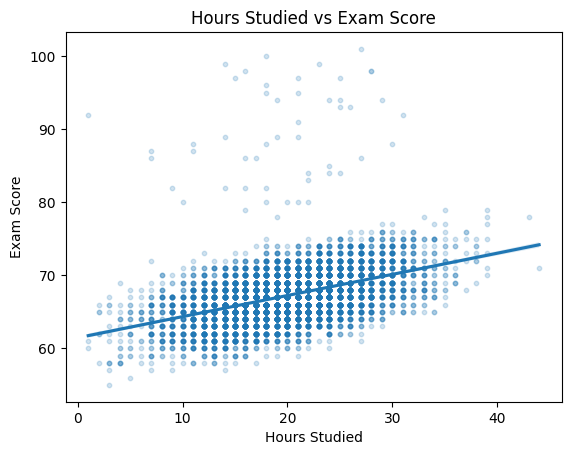

In [ ]:
sns.regplot(data=df, x='Hours_Studied', y='Exam_Score', scatter_kws={'alpha': 0.2, 's': 10})

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

In [8]:
r, p = pearsonr(df['Hours_Studied'], df['Exam_Score'])
print(f"r = {r:.2f}, p = {p:.4f}")
print("Significant!" if p < ALPHA else "Not enough evidence")

r = 0.45, p = 0.0000
Significant!


Moderate positive correlation (r=0.45). More studying does help.

### Q2: Attendance vs Exam Score

Assumption: higher attendance = better scores

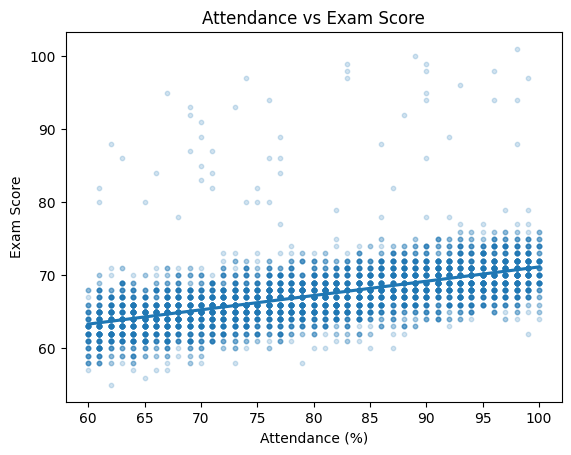

In [9]:
sns.regplot(data=df, x='Attendance', y='Exam_Score', scatter_kws={'alpha': 0.2, 's': 10})
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')

plt.show()

In [10]:
r, p = pearsonr(df['Attendance'], df['Exam_Score'])

print(f"r = {r:.2f}, p = {p:.4f}")

print("Significant!" if p < ALPHA else "Not enough evidence")

r = 0.58, p = 0.0000
Significant!


Strongest correlation so far (r=0.58). Attendance matters more than study hours.

### Q3: Previous Scores vs Exam Score

Assumption: students who did well before will do well again

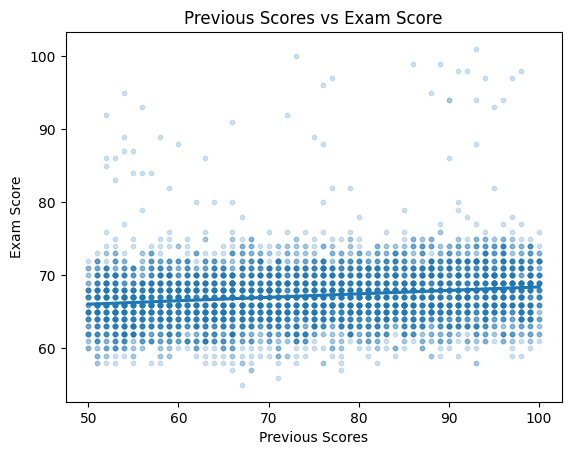

In [11]:
sns.regplot(data=df, x='Previous_Scores', y='Exam_Score', scatter_kws={'alpha': 0.2, 's': 10})
plt.title('Previous Scores vs Exam Score')
plt.xlabel('Previous Scores')
plt.ylabel('Exam Score')
plt.show()

In [12]:
r, p = pearsonr(df['Previous_Scores'], df['Exam_Score'])

print(f"r = {r:.2f}, p = {p:.4f}")

print("Significant!" if p < ALPHA else "Not enough evidence")

r = 0.18, p = 0.0000
Significant!


Surprisingly weak (r=0.18). Significant but previous scores alone don't tell you much.

### Q4: Motivation Level vs Exam Score

Assumption: more motivated students score higher

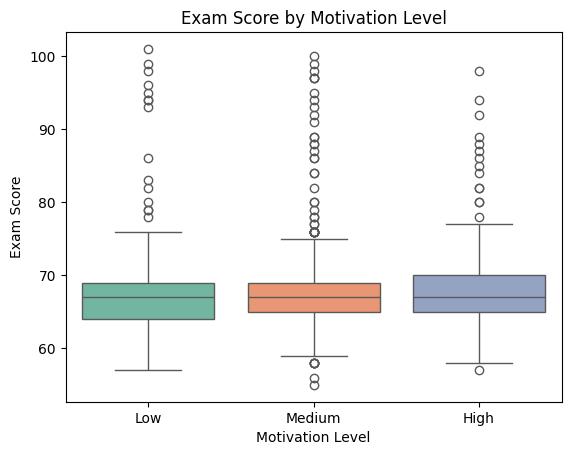

In [13]:
sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score', order=['Low', 'Medium', 'High'],
            hue='Motivation_Level', palette='Set2', legend=False)

plt.title('Exam Score by Motivation Level')
plt.xlabel('Motivation Level')
plt.ylabel('Exam Score')

plt.show()

In [14]:
tukey = pairwise_tukeyhsd(df['Exam_Score'], df['Motivation_Level'], ALPHA)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low  -0.9521    0.0 -1.2765 -0.6278   True
  High Medium  -0.3737 0.0085  -0.669 -0.0783   True
   Low Medium   0.5785    0.0  0.3191  0.8378   True
----------------------------------------------------


All pairs are significantly different. High motivation scores about 1 point more than Low. Small but real.

### Q5: Parental Involvement vs Exam Score

Assumption: involved parents help their kids score better

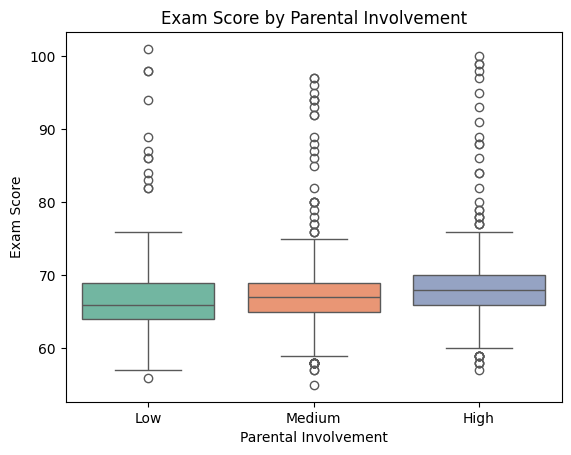

In [15]:
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', order=['Low', 'Medium', 'High'],
            hue='Parental_Involvement', palette='Set2', legend=False)

plt.title('Exam Score by Parental Involvement')
plt.xlabel('Parental Involvement')
plt.ylabel('Exam Score')

plt.show()

In [16]:
tukey = pairwise_tukeyhsd(df['Exam_Score'], df['Parental_Involvement'], ALPHA)

print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.7345   0.0 -2.0557 -1.4133   True
  High Medium  -0.9946   0.0 -1.2528 -0.7364   True
   Low Medium   0.7399   0.0  0.4487  1.0311   True
---------------------------------------------------


All pairs significant. Biggest categorical effect so far, about 1.7 points between High and Low involvement.

### Q6: Family Income vs Exam Score

Assumption: higher income = better resources = higher scores

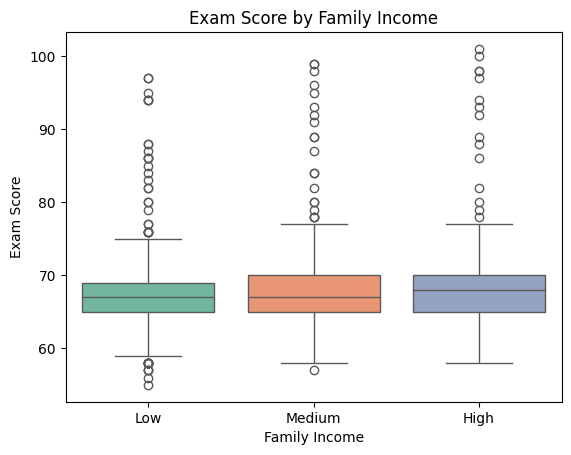

In [17]:
sns.boxplot(data=df, x='Family_Income', y='Exam_Score', order=['Low', 'Medium', 'High'],
            hue='Family_Income', palette='Set2', legend=False)
plt.title('Exam Score by Family Income')
plt.xlabel('Family Income')
plt.ylabel('Exam Score')
plt.show()

In [18]:
tukey = pairwise_tukeyhsd(df['Exam_Score'], df['Family_Income'], ALPHA)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low   -0.994    0.0 -1.3035 -0.6844   True
  High Medium  -0.5074 0.0004 -0.8171 -0.1977   True
   Low Medium   0.4865    0.0   0.238  0.7351   True
----------------------------------------------------


All pairs significant. About 1 point gap between High and Low income.

### Q7: Learning Disabilities vs Exam Score

Assumption: students with learning disabilities might score lower

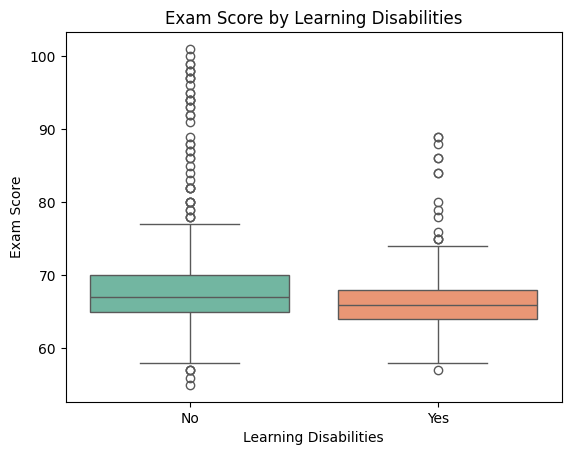

In [19]:
sns.boxplot(data=df, x='Learning_Disabilities', y='Exam_Score',
            hue='Learning_Disabilities', palette='Set2', legend=False)

plt.title('Exam Score by Learning Disabilities')
plt.xlabel('Learning Disabilities')
plt.ylabel('Exam Score')

plt.show()

In [20]:
no_dis = df[df['Learning_Disabilities'] == 'No']['Exam_Score']
yes_dis = df[df['Learning_Disabilities'] == 'Yes']['Exam_Score']

t, p = ttest_ind(no_dis, yes_dis)

print(f"t = {t:.2f}, p = {p:.4f}")
print(f"No: {no_dis.mean():.2f}, Yes: {yes_dis.mean():.2f}")

print("Significant!" if p < ALPHA else "Not enough evidence")

t = 6.94, p = 0.0000
No: 67.35, Yes: 66.27
Significant!


Significant. Students with disabilities score about 1 point lower (67.35 vs 66.27).

### Q8: Internet Access vs Exam Score

Assumption: internet access gives students more resources

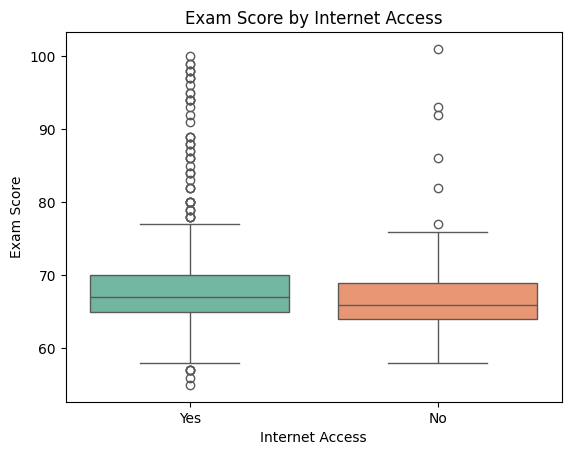

In [21]:
sns.boxplot(data=df, x='Internet_Access', y='Exam_Score',
            hue='Internet_Access', palette='Set2', legend=False)
plt.title('Exam Score by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Exam Score')
plt.show()

In [22]:
yes_int = df[df['Internet_Access'] == 'Yes']['Exam_Score']
no_int = df[df['Internet_Access'] == 'No']['Exam_Score']

t, p = ttest_ind(yes_int, no_int)
print(f"t = {t:.2f}, p = {p:.4f}")
print(f"Yes: {yes_int.mean():.2f}, No: {no_int.mean():.2f}")
print("Significant!" if p < ALPHA else "Not enough evidence")

t = 4.19, p = 0.0000
Yes: 67.29, No: 66.54
Significant!


Significant but small difference, about 0.75 points.

### Q9: Gender vs Exam Score

Assumption: not sure, lets check if there is a difference

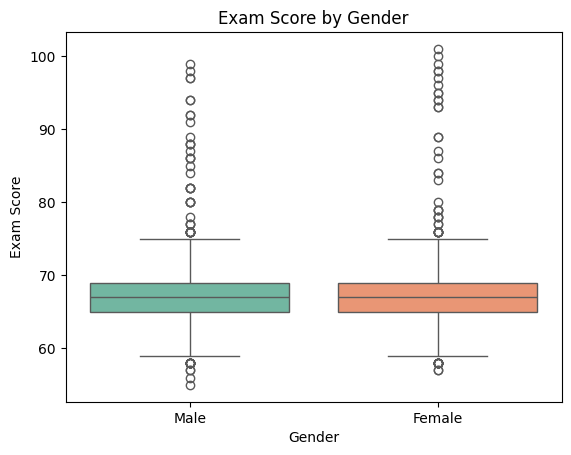

In [23]:
sns.boxplot(data=df, x='Gender', y='Exam_Score',
            hue='Gender', palette='Set2', legend=False)
plt.title('Exam Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Exam Score')
plt.show()

In [24]:
male = df[df['Gender'] == 'Male']['Exam_Score']
female = df[df['Gender'] == 'Female']['Exam_Score']

t, p = ttest_ind(male, female)
print(f"t = {t:.2f}, p = {p:.4f}")
print(f"Male: {male.mean():.2f}, Female: {female.mean():.2f}")
print("Significant!" if p < ALPHA else "Not enough evidence")

t = -0.17, p = 0.8688
Male: 67.23, Female: 67.24
Not enough evidence


Not significant (p=0.87). No difference between male and female scores.

### Q10: Internet Access vs Family Income

Assumption: richer families more likely to have internet

In [25]:
contingency = pd.crosstab(df['Internet_Access'], df['Family_Income'])
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
v = association(contingency, method='cramer', correction=True)

print(f"\nChi2 = {chi2:.2f}, p = {p:.4f}")
print(f"Cramer's V = {v:.4f}")
print("Significant!" if p < ALPHA else "Not enough evidence")

Family_Income    High   Low  Medium
Internet_Access                    
No                102   211     186
Yes              1167  2461    2480

Chi2 = 2.15, p = 0.3418
Cramer's V = 0.0180
Not enough evidence


Not significant (p=0.34). Internet access is pretty evenly spread across income levels in this data.

## Summary

### Insights

1. **Attendance is the strongest predictor** of exam scores (r=0.58), even more than study hours
2. **Study hours help** but with a moderate effect (r=0.45)
3. **Previous scores are surprisingly weak** predictors (r=0.18)
4. **Parental involvement** has the biggest categorical effect (~1.7 pt gap between High and Low)
5. **Motivation matters** across all levels, about 1 point difference between High and Low
6. **Family income affects scores** with about 1 point gap across levels
7. **Learning disabilities** lead to about 1 point lower scores
8. **Internet access** gives a small but significant advantage (~0.75 pts)
9. **Gender has no effect** on exam scores at all (p=0.87)
10. **Internet access is not linked to income** in this dataset, which was surprising